# Cross-Province TFT Comparison

Compares TFT solar forecast performance across three Spanish provinces:
- **Cáceres** (Extremadura) — inland, semi-arid, 2,463 MWp top-8
- **Cádiz** (Andalucía) — coastal lowland, 715 MWp top-8
- **Zaragoza** (Aragón) — Ebro valley, 462 MWp top-8

For each province, three TFT variants were trained:
1. **Standard** — weather as observed (encoder-only)
2. **NWP** — Open-Meteo forecasts as known-future (encoder + decoder)
3. **Perfect forecast** — ERA5 reanalysis as known-future (performance ceiling)

**Key question:** Does the pattern from Cáceres (NWP ≈ perfect forecast >> standard) hold across geographically diverse provinces?

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. Province Configuration

In [2]:
# Province definitions
PROVINCES = {
    'Cáceres': {
        'dir': 'caceres_analysis',
        'capacity_mwp': 2463.01,
        'n_plants': 8,
        'region': 'Extremadura',
        'climate': 'Inland semi-arid',
    },
    'Cádiz': {
        'dir': 'cadiz_analysis',
        'capacity_mwp': 714.60,
        'n_plants': 8,
        'region': 'Andalucía',
        'climate': 'Coastal lowland',
    },
    'Zaragoza': {
        'dir': 'zaragoza_analysis',
        'capacity_mwp': 462.40,
        'n_plants': 8,
        'region': 'Aragón',
        'climate': 'Ebro valley continental',
    },
}

# Navigate to project root
PROJECT_ROOT = os.getcwd()
# If running from a subdirectory, try to find the project root
if not os.path.isdir(os.path.join(PROJECT_ROOT, 'caceres_analysis')):
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')
for name, info in PROVINCES.items():
    exists = os.path.isdir(os.path.join(PROJECT_ROOT, info['dir']))
    print(f"  {name:12s}  {info['dir']:25s}  exists={exists}")

Project root: /home/tzf/bachelor/MLVU/project/ML-solar-forecast
  Cáceres       caceres_analysis           exists=True
  Cádiz         cadiz_analysis             exists=True
  Zaragoza      zaragoza_analysis          exists=True


## 2. Load Results

In [3]:
def load_metrics(province_dir, json_paths, metrics_key, fallback_key):
    """Load metrics from a JSON results file. Tries multiple paths.
    Returns dict with R2, RMSE_MWh, MAE_MWh or None."""
    if isinstance(json_paths, str):
        json_paths = [json_paths]
    for json_path in json_paths:
        full_path = os.path.join(PROJECT_ROOT, province_dir, json_path)
        if os.path.exists(full_path):
            with open(full_path) as f:
                data = json.load(f)
            metrics = data.get(metrics_key) or data.get(fallback_key)
            if metrics:
                print(f'  Found: {province_dir}/{json_path} -> {list(metrics.keys())}')
                return metrics
    return None


def get_peak_generation(province_dir, province_name):
    """Get peak hourly generation from the assembled dataset (= ESIOS total provincial PV)."""
    csv_name = province_name.lower() + '_assembled_dataset.csv'
    csv_path = os.path.join(PROJECT_ROOT, province_dir, 'data', csv_name)
    df = pd.read_csv(csv_path, usecols=['pv_generation_gwh'])  # column name is gwh but unit is MWh
    return df['pv_generation_gwh'].max()


# Model variants and where their results are stored
# Multiple candidate paths per model to handle naming differences across provinces
MODELS = {
    'Standard (no NWP)': {
        'json': ['models/hp_study_results.json'],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
    'NWP (Open-Meteo)': {
        'json': [
            'models/nwp_forecast/nwp_hp_study_results.json',  # Cádiz/Zaragoza naming
            'models/nwp_forecast/hp_study_results.json',       # alternative naming
        ],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
    'Perfect forecast (ERA5)': {
        'json': ['models/perfect_forecast/hp_study_results_pf.json'],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
}

# Collect all results + compute peak generation per province for proper nRMSE
rows = []
for prov_name, prov_info in PROVINCES.items():
    print(f'\n{prov_name}:')
    
    # Get peak generation from ESIOS data (total provincial PV, not just top-8)
    peak_gen = get_peak_generation(prov_info['dir'], prov_name.replace('á', 'a').replace('é', 'e'))
    prov_info['peak_gen_mwh'] = peak_gen
    print(f'  Peak ESIOS generation: {peak_gen:.1f} MWh  (top-8 capacity: {prov_info["capacity_mwp"]:.0f} MWp, ratio: {peak_gen/prov_info["capacity_mwp"]:.2f}x)')
    
    for model_name, model_info in MODELS.items():
        metrics = load_metrics(
            prov_info['dir'],
            model_info['json'],
            model_info['metrics_key'],
            model_info['fallback_key'],
        )
        if metrics:
            rows.append({
                'Province': prov_name,
                'Model': model_name,
                'R2': metrics.get('R2'),
                'RMSE_MWh': metrics.get('RMSE_MWh'),
                'MAE_MWh': metrics.get('MAE_MWh'),
                'Capacity_MWp': prov_info['capacity_mwp'],
                'Peak_Gen_MWh': peak_gen,
            })
        else:
            print(f'  MISSING: {model_name}')
            rows.append({
                'Province': prov_name,
                'Model': model_name,
                'R2': None, 'RMSE_MWh': None, 'MAE_MWh': None,
                'Capacity_MWp': prov_info['capacity_mwp'],
                'Peak_Gen_MWh': peak_gen,
            })

results = pd.DataFrame(rows)

# nRMSE normalized by peak observed generation (fair cross-province comparison)
# This accounts for the fact that ESIOS covers ALL provincial PV, not just the top-8 plants
results['nRMSE_pct'] = (results['RMSE_MWh'] / results['Peak_Gen_MWh'] * 100).round(2)

n_found = results['R2'].notna().sum()
n_total = len(results)
print(f'\nLoaded {n_found}/{n_total} model results ({n_total - n_found} missing)')
results


Cáceres:
  Peak ESIOS generation: 2959.8 MWh  (top-8 capacity: 2463 MWp, ratio: 1.20x)
  Found: caceres_analysis/models/hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: caceres_analysis/models/nwp_forecast/nwp_hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: caceres_analysis/models/perfect_forecast/hp_study_results_pf.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']

Cádiz:
  Peak ESIOS generation: 1480.6 MWh  (top-8 capacity: 715 MWp, ratio: 2.07x)
  Found: cadiz_analysis/models/hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: cadiz_analysis/models/nwp_forecast/nwp_hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: cadiz_analysis/models/perfect_forecast/hp_study_results_pf.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']

Zaragoza:
  Peak ESIOS generation: 1646.8 MWh  (top-8 capacity: 462 MWp, ratio: 3.56x)
  Found: zaragoza_analysis/models/hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: zaragoza_analysis/models/nwp_forecast/nwp_hp_

,Province,Model,R2,RMSE_MWh,MAE_MWh,Capacity_MWp,Peak_Gen_MWh,nRMSE_pct
0,Cáceres,Standard (no NWP),0.839099,334.417236,179.965820,2463.01,2959.799,11.30
1,Cáceres,NWP (Open-Meteo),0.885869,281.650238,151.946060,2463.01,2959.799,9.52
2,Cáceres,Perfect forecast (ERA5),0.888624,278.230865,145.504028,2463.01,2959.799,9.40
3,Cádiz,Standard (no NWP),0.696950,218.379471,124.684715,714.60,1480.592,14.75
4,Cádiz,NWP (Open-Meteo),0.761473,193.741882,108.499535,714.60,1480.592,13.09
5,Cádiz,Perfect forecast (ERA5),0.704599,215.605865,122.561928,714.60,1480.592,14.56
6,Zaragoza,Standard (no NWP),0.782491,214.515244,119.378227,462.40,1646.762,13.03
7,Zaragoza,NWP (Open-Meteo),0.864048,169.594635,91.497513,462.40,1646.762,10.30
8,Zaragoza,Perfect forecast (ERA5),0.893185,163.355423,87.273727,462.40,1646.762,9.92


## 3. Three-Way Comparison per Province

In [4]:
for prov_name in PROVINCES:
    prov_results = results[results['Province'] == prov_name].copy()
    cap = PROVINCES[prov_name]['capacity_mwp']
    climate = PROVINCES[prov_name]['climate']
    
    print('=' * 70)
    print(f'THREE-WAY COMPARISON — {prov_name} ({climate}, {cap:.0f} MWp)')
    print('=' * 70)
    print(f'{"Model":35s} {"RMSE (MWh)":>12s} {"MAE (MWh)":>11s} {"R²":>8s} {"nRMSE %":>8s}')
    print('-' * 70)
    
    for _, row in prov_results.iterrows():
        if row['R2'] is not None and not pd.isna(row['R2']):
            print(f'{row["Model"]:35s} {row["RMSE_MWh"]:>12.2f} {row["MAE_MWh"]:>11.2f} {row["R2"]:>8.4f} {row["nRMSE_pct"]:>7.2f}%')
        else:
            print(f'{row["Model"]:35s} {"—":>12s} {"—":>11s} {"—":>8s} {"—":>8s}')
    
    # Extract R² per model using exact match
    std_r2 = prov_results.loc[prov_results['Model'] == 'Standard (no NWP)', 'R2'].values
    nwp_r2 = prov_results.loc[prov_results['Model'] == 'NWP (Open-Meteo)', 'R2'].values
    pf_r2  = prov_results.loc[prov_results['Model'] == 'Perfect forecast (ERA5)', 'R2'].values
    
    if len(std_r2) and len(nwp_r2) and pd.notna(std_r2[0]) and pd.notna(nwp_r2[0]):
        print(f'\n  NWP vs Standard:     ΔR² = {nwp_r2[0] - std_r2[0]:+.4f}')
    if len(nwp_r2) and len(pf_r2) and pd.notna(nwp_r2[0]) and pd.notna(pf_r2[0]):
        print(f'  Perfect vs NWP:      ΔR² = {pf_r2[0] - nwp_r2[0]:+.4f}')
    if len(std_r2) and len(pf_r2) and pd.notna(std_r2[0]) and pd.notna(pf_r2[0]):
        print(f'  Perfect vs Standard: ΔR² = {pf_r2[0] - std_r2[0]:+.4f}')
    if len(std_r2) and len(nwp_r2) and len(pf_r2) and all(pd.notna(v[0]) for v in [std_r2, nwp_r2, pf_r2]):
        total_gap = pf_r2[0] - std_r2[0]
        nwp_gain  = nwp_r2[0] - std_r2[0]
        if total_gap > 0:
            print(f'  NWP captures {nwp_gain/total_gap*100:.1f}% of the perfect-forecast improvement')
    print()

THREE-WAY COMPARISON — Cáceres (Inland semi-arid, 2463 MWp)
Model                                 RMSE (MWh)   MAE (MWh)       R²  nRMSE %
----------------------------------------------------------------------
Standard (no NWP)                         334.42      179.97   0.8391   11.30%
NWP (Open-Meteo)                          281.65      151.95   0.8859    9.52%
Perfect forecast (ERA5)                   278.23      145.50   0.8886    9.40%

  NWP vs Standard:     ΔR² = +0.0468
  Perfect vs NWP:      ΔR² = +0.0028
  Perfect vs Standard: ΔR² = +0.0495
  NWP captures 94.4% of the perfect-forecast improvement

THREE-WAY COMPARISON — Cádiz (Coastal lowland, 715 MWp)
Model                                 RMSE (MWh)   MAE (MWh)       R²  nRMSE %
----------------------------------------------------------------------
Standard (no NWP)                         218.38      124.68   0.6969   14.75%
NWP (Open-Meteo)                          193.74      108.50   0.7615   13.09%
Perfect forecast (E

## 4. Cross-Province Pivot Table

In [5]:
# Pivot: provinces as rows, models as columns
available = results.dropna(subset=['R2'])

if len(available) > 0:
    pivot_r2 = available.pivot(index='Province', columns='Model', values='R2')
    pivot_rmse = available.pivot(index='Province', columns='Model', values='RMSE_MWh')
    pivot_nrmse = available.pivot(index='Province', columns='Model', values='nRMSE_pct')

    # Reorder columns
    col_order = ['Standard (no NWP)', 'NWP (Open-Meteo)', 'Perfect forecast (ERA5)']
    col_order = [c for c in col_order if c in pivot_r2.columns]

    print('=== R² by Province and Model ===')
    print(pivot_r2[col_order].round(4).to_string())

    print('\n=== RMSE (MWh) by Province and Model ===')
    print(pivot_rmse[col_order].round(2).to_string())

    print('\n=== nRMSE (% of peak observed generation) by Province and Model ===')
    print(pivot_nrmse[col_order].round(2).to_string())
else:
    print('No results available yet. Run the training/evaluation pipelines first.')

=== R² by Province and Model ===
Model     Standard (no NWP)  NWP (Open-Meteo)  Perfect forecast (ERA5)
Province                                                              
Cáceres              0.8391            0.8859                   0.8886
Cádiz                0.6969            0.7615                   0.7046
Zaragoza             0.7825            0.8640                   0.8932

=== RMSE (MWh) by Province and Model ===
Model     Standard (no NWP)  NWP (Open-Meteo)  Perfect forecast (ERA5)
Province                                                              
Cáceres              334.42            281.65                   278.23
Cádiz                218.38            193.74                   215.61
Zaragoza             214.52            169.59                   163.36

=== nRMSE (% of peak observed generation) by Province and Model ===
Model     Standard (no NWP)  NWP (Open-Meteo)  Perfect forecast (ERA5)
Province                                                              
Cáce

## 5. Visualizations

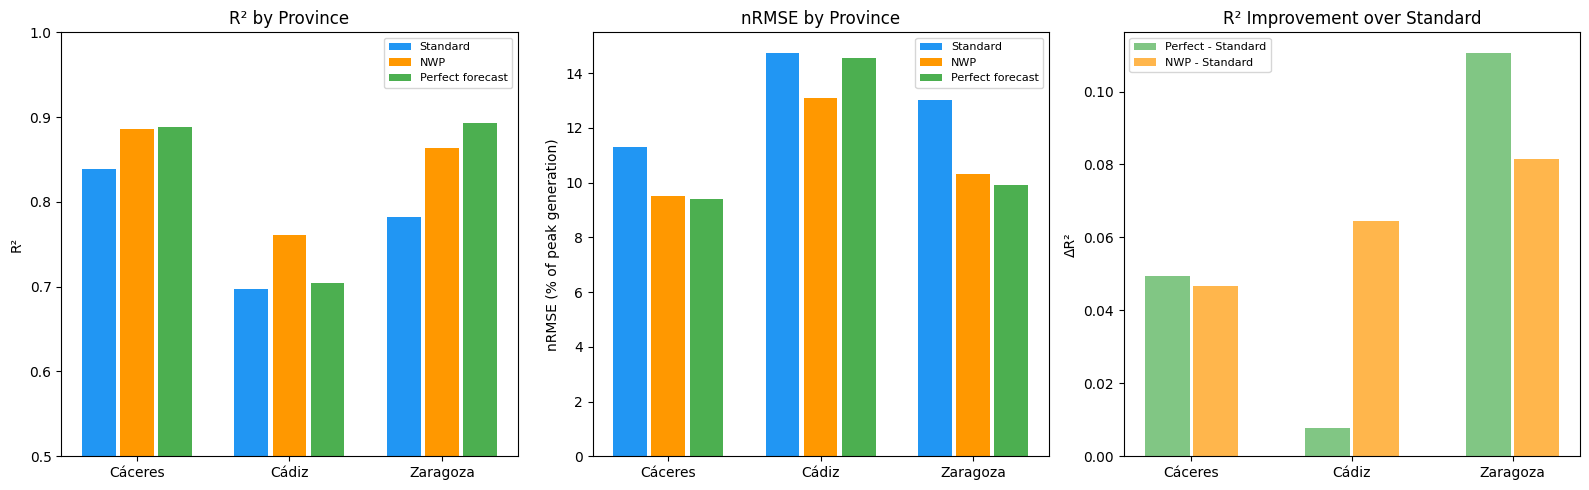

In [6]:
available = results.dropna(subset=['R2'])

if len(available) >= 3:  # Need at least one province with all 3 models
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    col_order = ['Standard (no NWP)', 'NWP (Open-Meteo)', 'Perfect forecast (ERA5)']
    colors = ['#2196F3', '#FF9800', '#4CAF50']
    prov_names = list(PROVINCES.keys())

    # (a) R² comparison
    for i, model in enumerate(col_order):
        vals = []
        for prov in prov_names:
            row = available[(available['Province'] == prov) & (available['Model'] == model)]
            vals.append(row['R2'].values[0] if len(row) > 0 else 0)
        x = np.arange(len(prov_names)) + i * 0.25
        axes[0].bar(x, vals, 0.22, label=model.split('(')[0].strip(), color=colors[i])
    axes[0].set_xticks(np.arange(len(prov_names)) + 0.25)
    axes[0].set_xticklabels(prov_names)
    axes[0].set_ylabel('R²')
    axes[0].set_title('R² by Province')
    axes[0].legend(fontsize=8)
    axes[0].set_ylim(0.5, 1.0)

    # (b) nRMSE comparison (normalized by peak generation)
    for i, model in enumerate(col_order):
        vals = []
        for prov in prov_names:
            row = available[(available['Province'] == prov) & (available['Model'] == model)]
            vals.append(row['nRMSE_pct'].values[0] if len(row) > 0 else 0)
        x = np.arange(len(prov_names)) + i * 0.25
        axes[1].bar(x, vals, 0.22, label=model.split('(')[0].strip(), color=colors[i])
    axes[1].set_xticks(np.arange(len(prov_names)) + 0.25)
    axes[1].set_xticklabels(prov_names)
    axes[1].set_ylabel('nRMSE (% of peak generation)')
    axes[1].set_title('nRMSE by Province')
    axes[1].legend(fontsize=8)

    # (c) ΔR² NWP improvement
    deltas_nwp = []
    deltas_pf = []
    for prov in prov_names:
        std = available[(available['Province'] == prov) & (available['Model'] == col_order[0])]
        nwp = available[(available['Province'] == prov) & (available['Model'] == col_order[1])]
        pf  = available[(available['Province'] == prov) & (available['Model'] == col_order[2])]
        d_nwp = (nwp['R2'].values[0] - std['R2'].values[0]) if len(std) and len(nwp) else 0
        d_pf  = (pf['R2'].values[0] - std['R2'].values[0]) if len(std) and len(pf) else 0
        deltas_nwp.append(d_nwp)
        deltas_pf.append(d_pf)

    x = np.arange(len(prov_names))
    axes[2].bar(x - 0.15, deltas_pf, 0.28, label='Perfect - Standard', color='#4CAF50', alpha=0.7)
    axes[2].bar(x + 0.15, deltas_nwp, 0.28, label='NWP - Standard', color='#FF9800', alpha=0.7)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(prov_names)
    axes[2].set_ylabel('ΔR²')
    axes[2].set_title('R² Improvement over Standard')
    axes[2].legend(fontsize=8)
    axes[2].axhline(0, color='black', lw=0.5)

    plt.tight_layout()
    plt.show()
else:
    print('Not enough results for visualization. Run pipelines for at least one full province first.')

## 6. Summary

In [7]:
available = results.dropna(subset=['R2'])

if len(available) >= 6:  # At least 2 provinces with results
    print('=' * 70)
    print('CROSS-PROVINCE SUMMARY')
    print('=' * 70)

    col_order = ['Standard (no NWP)', 'NWP (Open-Meteo)', 'Perfect forecast (ERA5)']
    prov_names = list(PROVINCES.keys())

    # Summary table
    print(f'\n{"Province":12s} {"Capacity":>10s} {"Std R²":>8s} {"NWP R²":>8s} {"PF R²":>8s} {"ΔR² NWP-Std":>12s} {"NWP/PF gap":>10s}')
    print('-' * 70)

    for prov in prov_names:
        cap = PROVINCES[prov]['capacity_mwp']
        vals = {}
        for model in col_order:
            row = available[(available['Province'] == prov) & (available['Model'] == model)]
            vals[model] = row['R2'].values[0] if len(row) > 0 else None

        std_str = f'{vals[col_order[0]]:.4f}' if vals[col_order[0]] is not None else '—'
        nwp_str = f'{vals[col_order[1]]:.4f}' if vals[col_order[1]] is not None else '—'
        pf_str  = f'{vals[col_order[2]]:.4f}' if vals[col_order[2]] is not None else '—'

        if vals[col_order[0]] is not None and vals[col_order[1]] is not None:
            delta = vals[col_order[1]] - vals[col_order[0]]
            delta_str = f'{delta:+.4f}'
        else:
            delta_str = '—'

        if vals[col_order[1]] is not None and vals[col_order[2]] is not None:
            gap = vals[col_order[2]] - vals[col_order[1]]
            gap_str = f'{gap:+.4f}'
        else:
            gap_str = '—'

        print(f'{prov:12s} {cap:>8.0f}MW {std_str:>8s} {nwp_str:>8s} {pf_str:>8s} {delta_str:>12s} {gap_str:>10s}')

    # Cross-province averages
    print('\n--- Averages across provinces ---')
    for model in col_order:
        model_data = available[available['Model'] == model]
        if len(model_data) > 0:
            print(f'{model:35s}  mean R²={model_data["R2"].mean():.4f}  mean nRMSE={model_data["nRMSE_pct"].mean():.2f}%')

    print('\n--- Key Findings ---')
    # Check if NWP consistently improves over standard
    for prov in prov_names:
        std_row = available[(available['Province'] == prov) & (available['Model'] == col_order[0])]
        nwp_row = available[(available['Province'] == prov) & (available['Model'] == col_order[1])]
        if len(std_row) > 0 and len(nwp_row) > 0:
            improvement = nwp_row['R2'].values[0] > std_row['R2'].values[0]
            print(f'  {prov}: NWP {"improves" if improvement else "does NOT improve"} over Standard')
else:
    print('Need results from at least 2 provinces to generate summary.')
    print(f'Currently have {len(available)} results. Run the remaining pipelines.')

CROSS-PROVINCE SUMMARY

Province       Capacity   Std R²   NWP R²    PF R²  ΔR² NWP-Std NWP/PF gap
----------------------------------------------------------------------
Cáceres          2463MW   0.8391   0.8859   0.8886      +0.0468    +0.0028
Cádiz             715MW   0.6969   0.7615   0.7046      +0.0645    -0.0569
Zaragoza          462MW   0.7825   0.8640   0.8932      +0.0816    +0.0291

--- Averages across provinces ---
Standard (no NWP)                    mean R²=0.7728  mean nRMSE=13.03%
NWP (Open-Meteo)                     mean R²=0.8371  mean nRMSE=10.97%
Perfect forecast (ERA5)              mean R²=0.8288  mean nRMSE=11.29%

--- Key Findings ---
  Cáceres: NWP improves over Standard
  Cádiz: NWP improves over Standard
  Zaragoza: NWP improves over Standard
